In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/8-linear_regression-taxi/taxi_trip_pricing.csv")

df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [82]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [83]:
# Numeric → mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Categorical → mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [84]:
y = df["Trip_Price"]
X = df.drop("Trip_Price", axis=1)

In [85]:
X = pd.get_dummies(X, drop_first=True)


--- Feature: Trip_Distance_km ---
MSE: 441.8280216960773
RMSE: 21.019705556835884
R2: 0.4679104580007055


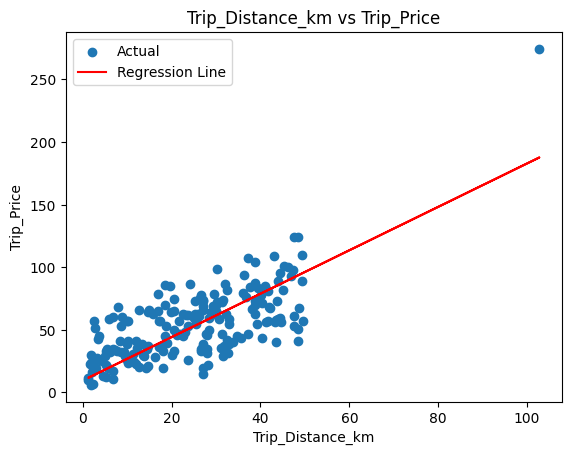


--- Feature: Passenger_Count ---
MSE: 849.8467172564401
RMSE: 29.1521305783375
R2: -0.023462814374495933


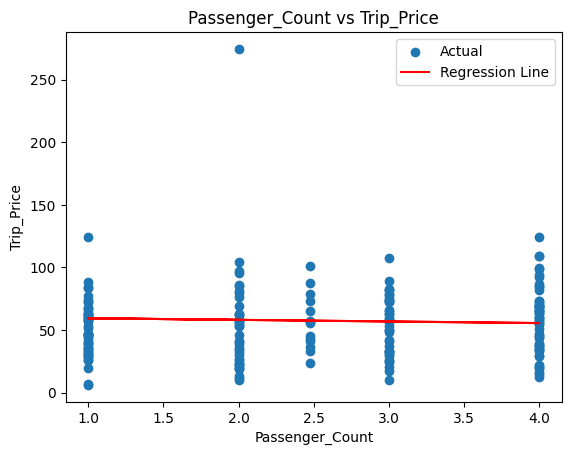


--- Feature: Base_Fare ---
MSE: 840.8979020277967
RMSE: 28.998239636705478
R2: -0.01268583608740892


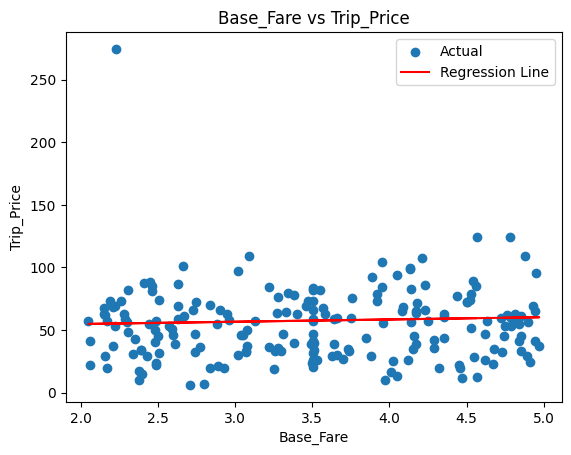


--- Feature: Per_Km_Rate ---
MSE: 647.4560247064229
RMSE: 25.4451571955534
R2: 0.22027448977036423


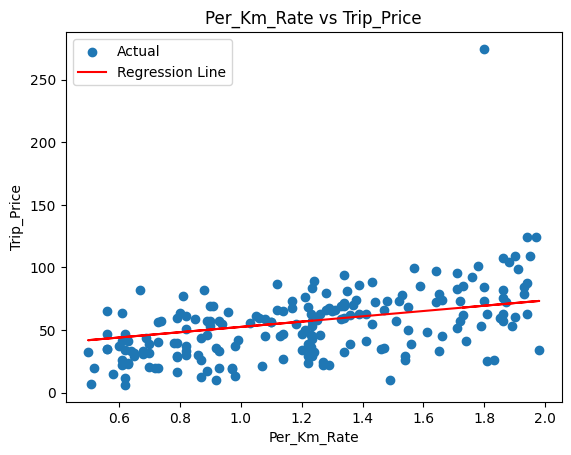


--- Feature: Per_Minute_Rate ---
MSE: 833.7087901720396
RMSE: 28.874015830362765
R2: -0.004028052862100617


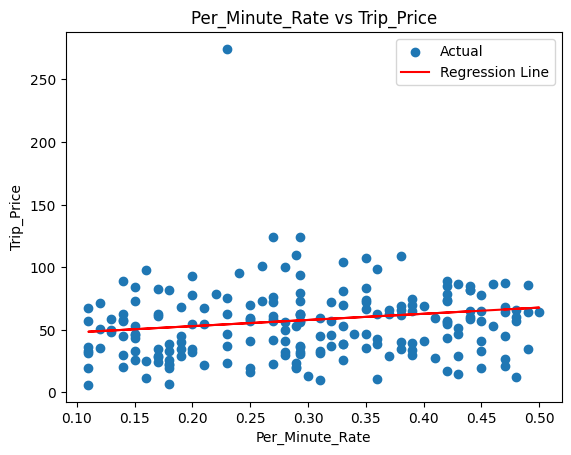


--- Feature: Trip_Duration_Minutes ---
MSE: 775.5160836872357
RMSE: 27.848089408202416
R2: 0.06605290402772268


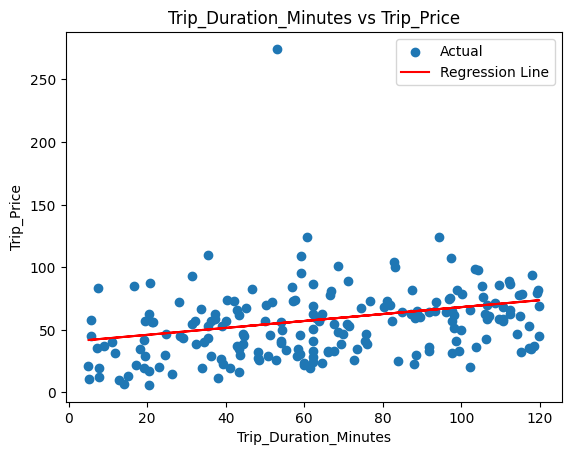


--- Feature: Time_of_Day_Evening ---
MSE: 840.3881310341719
RMSE: 28.989448615559628
R2: -0.012071923430893916


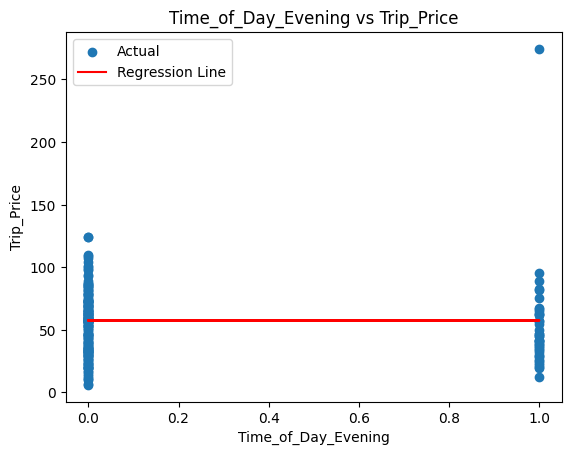


--- Feature: Time_of_Day_Morning ---
MSE: 841.0860170795189
RMSE: 29.0014830151756
R2: -0.012912381364754255


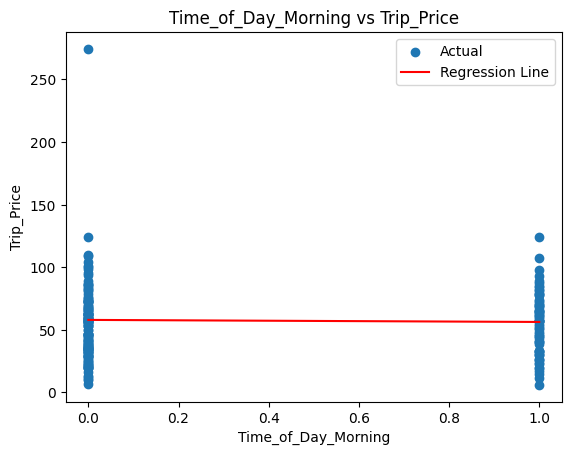


--- Feature: Time_of_Day_Night ---
MSE: 842.6557497768066
RMSE: 29.028533372817968
R2: -0.014802796437919818


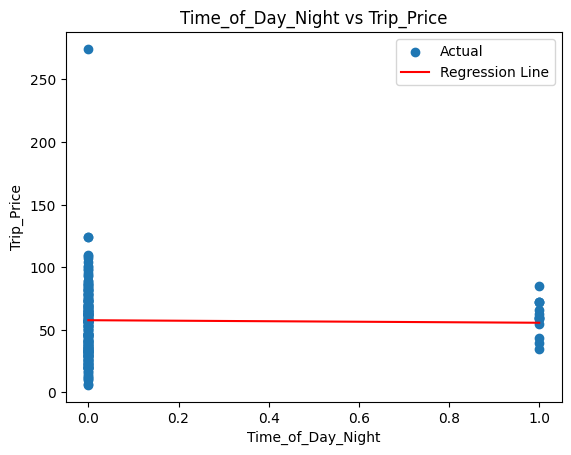


--- Feature: Day_of_Week_Weekend ---
MSE: 836.7352826338985
RMSE: 28.926376935833122
R2: -0.007672830714154921


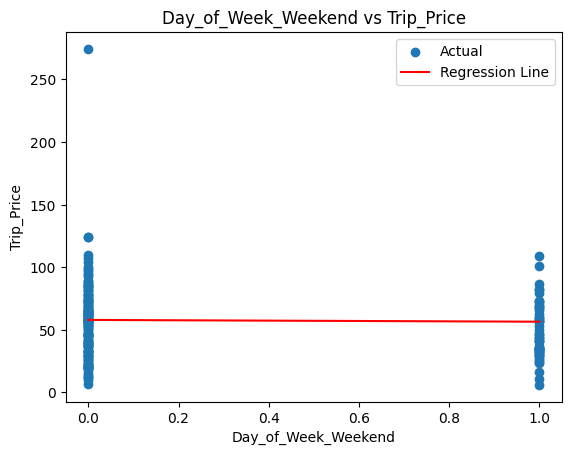


--- Feature: Traffic_Conditions_Low ---
MSE: 837.6879029931807
RMSE: 28.942838544157702
R2: -0.008820062908083903


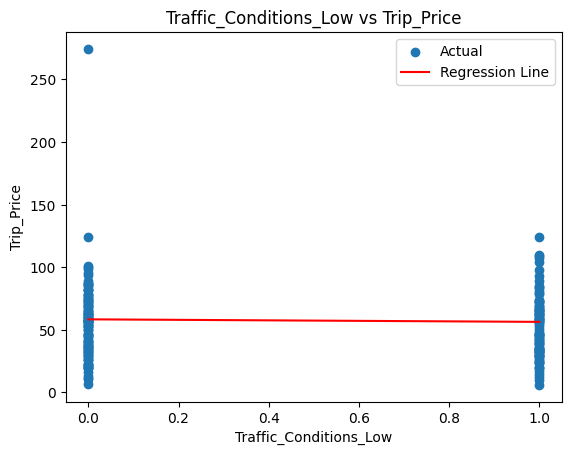


--- Feature: Traffic_Conditions_Medium ---
MSE: 859.4454866310922
RMSE: 29.31630069826499
R2: -0.03502252663699412


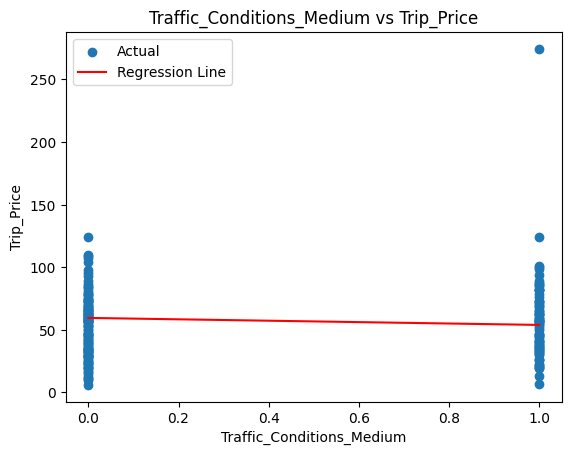


--- Feature: Weather_Rain ---
MSE: 850.1421751859287
RMSE: 29.157197656598083
R2: -0.02381863172120524


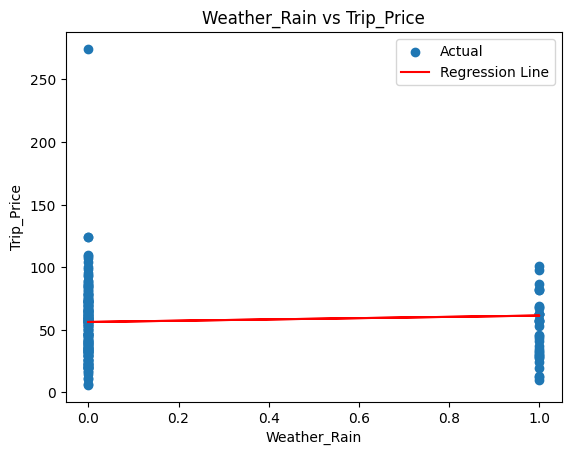


--- Feature: Weather_Snow ---
MSE: 840.639174599337
RMSE: 28.993778204975925
R2: -0.012374252955168252


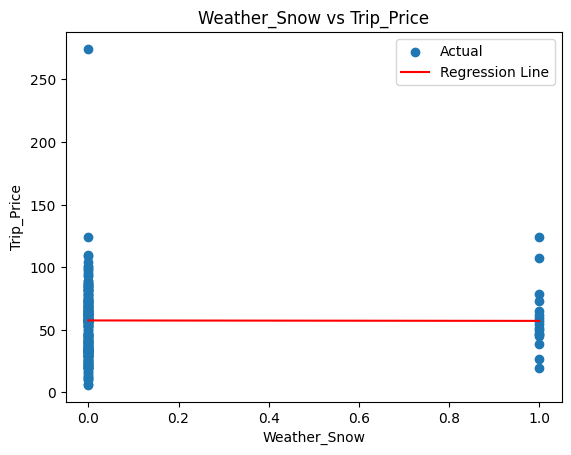

In [86]:
for col in X.columns:
    
    print(f"\n--- Feature: {col} ---")
    
    X_single = X[[col]]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    
    # Visualization
    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")
    plt.plot(X_test, y_pred, color='red', label="Regression Line")
    
    plt.xlabel(col)
    plt.ylabel("Trip_Price")
    plt.title(f"{col} vs Trip_Price")
    plt.legend()
    
    plt.show()

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [88]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\nMultiple Linear Regression")
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R2:", r2_multi)


Multiple Linear Regression
MSE: 194.72155605084473
RMSE: 13.954266589500314
R2: 0.7654985684729743


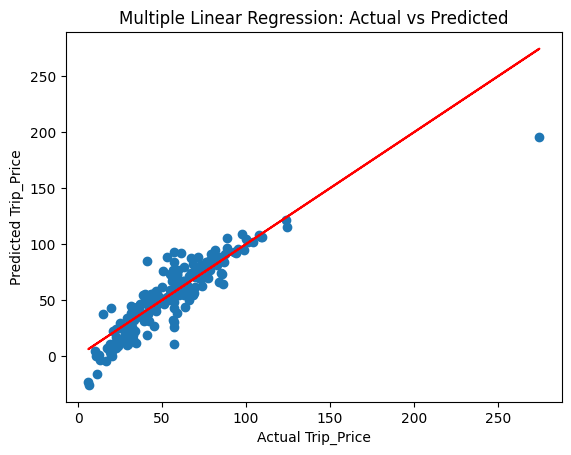

In [90]:
plt.figure()

plt.scatter(y_test, y_pred_multi)

# Ideal line
plt.plot(y_test, y_test, color='red')

plt.xlabel("Actual Trip_Price")
plt.ylabel("Predicted Trip_Price")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.show()